In [3]:
import gzip
import json
import pickle

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.impute import SimpleImputer
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeClassifier

We want to assess the credit risk from SMB in order to provide quantitative insights to the credit risk team. We use a ridge/lasso regression, or both, i.e. elastic net, avoiding overfitting as the tipology of firm diverges largely.

We select the top 10 features among the 50+ available to avoid correlation and overfitting. The features are selected based on decision tree feature importance and domain knowledge. The dataset contains 50+ features, including financial ratios, credit history, and demographic information.The selected features are:


In [51]:
df = wrangle("/Users/hirecheariles/Documents/Cours/Master Finance/ML/poland-bankruptcy-data-2009.json.gz")
print(df.shape)
df.head()

(9977, 65)


,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,feat_9,feat_10,...,feat_56,feat_57,feat_58,feat_59,feat_60,feat_61,feat_62,feat_63,feat_64,bankrupt
company_id,,,,,,,,,,,,,,,,,,,,,
1,0.174190,0.41299,0.14371,1.3480,-28.9820,0.60383,0.219460,1.12250,1.1961,0.46359,...,0.163960,0.375740,0.83604,0.000007,9.7145,6.2813,84.291,4.3303,4.0341,False
2,0.146240,0.46038,0.28230,1.6294,2.5952,0.00000,0.171850,1.17210,1.6018,0.53962,...,0.027516,0.271000,0.90108,0.000000,5.9882,4.1103,102.190,3.5716,5.9500,False
3,0.000595,0.22612,0.48839,3.1599,84.8740,0.19114,0.004572,2.98810,1.0077,0.67566,...,0.007639,0.000881,0.99236,0.000000,6.7742,3.7922,64.846,5.6287,4.4581,False
5,0.188290,0.41504,0.34231,1.9279,-58.2740,0.00000,0.233580,1.40940,1.3393,0.58496,...,0.176480,0.321880,0.82635,0.073039,2.5912,7.0756,100.540,3.6303,4.6375,False
6,0.182060,0.55615,0.32191,1.6045,16.3140,0.00000,0.182060,0.79808,1.8126,0.44385,...,0.555770,0.410190,0.46957,0.029421,8.4553,3.3488,107.240,3.4036,12.4540,False


<Axes: title={'center': 'Class Balance'}, xlabel='Bankrupt', ylabel='Frequency'>

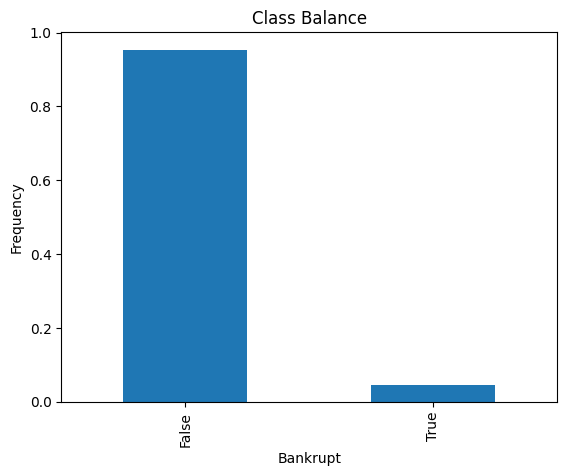

In [11]:
# Plot class balance
df["bankrupt"].value_counts(normalize=True).plot(
    kind="bar",
    xlabel = "Bankrupt",
    ylabel="Frequency",
    title="Class Balance"
)

We'll treat data imbalance with random oversampling and undersampling. We'll use a simple decision tree classifier to evaluate the performance of these techniques.

<Axes: >

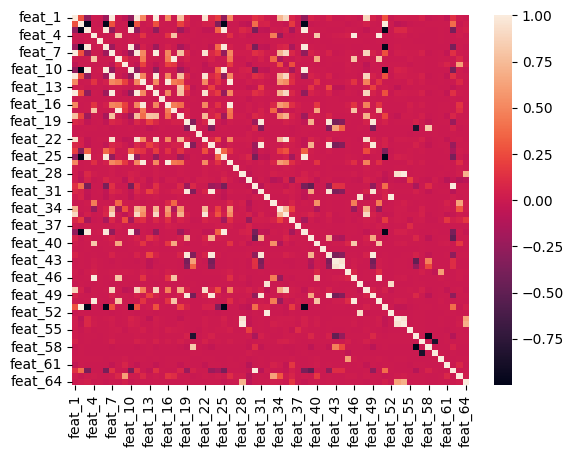

In [12]:
corr = df.drop(columns="bankrupt").corr()
sns.heatmap(corr)

We'll make sure as well to choose decorrelated features for our model, to avoid multicollinearity issues. We can use the heatmap to identify highly correlated features, even though they seem pretty uncorelated.

In [15]:
target = "bankrupt"
X = df.drop(columns="bankrupt")
y = df["bankrupt"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X shape: (9977, 64)
y shape: (9977,)
X_train shape: (7981, 64)
y_train shape: (7981,)
X_test shape: (1996, 64)
y_test shape: (1996,)


We opt for over-sampling the minority class to balance the dataset.

In [19]:
over_sampler = RandomOverSampler(random_state=42)
X_train_over, y_train_over = over_sampler.fit_resample(X, y)
print(X_train_over.shape)
X_train_over.head()

(19020, 64)


,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,feat_9,feat_10,...,feat_55,feat_56,feat_57,feat_58,feat_59,feat_60,feat_61,feat_62,feat_63,feat_64
0,0.174190,0.41299,0.14371,1.3480,-28.9820,0.60383,0.219460,1.12250,1.1961,0.46359,...,127280.0,0.163960,0.375740,0.83604,0.000007,9.7145,6.2813,84.291,4.3303,4.0341
1,0.146240,0.46038,0.28230,1.6294,2.5952,0.00000,0.171850,1.17210,1.6018,0.53962,...,3387.8,0.027516,0.271000,0.90108,0.000000,5.9882,4.1103,102.190,3.5716,5.9500
2,0.000595,0.22612,0.48839,3.1599,84.8740,0.19114,0.004572,2.98810,1.0077,0.67566,...,20453.0,0.007639,0.000881,0.99236,0.000000,6.7742,3.7922,64.846,5.6287,4.4581
3,0.188290,0.41504,0.34231,1.9279,-58.2740,0.00000,0.233580,1.40940,1.3393,0.58496,...,13730.0,0.176480,0.321880,0.82635,0.073039,2.5912,7.0756,100.540,3.6303,4.6375
4,0.182060,0.55615,0.32191,1.6045,16.3140,0.00000,0.182060,0.79808,1.8126,0.44385,...,2080.6,0.555770,0.410190,0.46957,0.029421,8.4553,3.3488,107.240,3.4036,12.4540


In [20]:
acc_baseline = y_train.value_counts(normalize=True).max()
print("Baseline Accuracy:", round(acc_baseline, 4))

Baseline Accuracy: 0.9519


In [21]:
# Fit on `X_train`, `y_train`

model_reg = make_pipeline(
    SimpleImputer(strategy="median"),
    DecisionTreeClassifier(random_state=42)
)
model_reg.fit(X_train, y_train)  

# Fit on `X_train_under`, `y_train_under`

model_under = make_pipeline(
    SimpleImputer(strategy="median"),
    DecisionTreeClassifier(random_state=42)
)
model_under.fit(X_train_under, y_train_under) 

# Fit on `X_train_over`, `y_train_over`

model_over = make_pipeline(
    SimpleImputer(strategy="median"),
    DecisionTreeClassifier(random_state=42)
)
model_over.fit(X_train_over, y_train_over)  

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('simpleimputer', ...), ('decisiontreeclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness desp

In [22]:
for m in [model_reg, model_under, model_over]:
    acc_train = m.score(X_train, y_train)
    acc_test = m.score(X_test, y_test)

    print("Training Accuracy:", round(acc_train, 4))
    print("Test Accuracy:", round(acc_test, 4))

Training Accuracy: 1.0
Test Accuracy: 0.9394
Training Accuracy: 0.7421
Test Accuracy: 0.7104
Training Accuracy: 1.0
Test Accuracy: 1.0


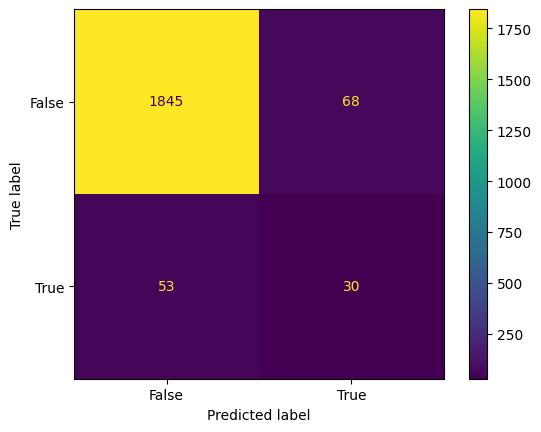

In [23]:
# Plot confusion matrix
cm = ConfusionMatrixDisplay.from_estimator(model_reg, X_test, y_test)

Now we get to the point where we analyse feature importance. We can use the `feature_importances_` attribute of the decision tree to see which features are most important for the model's predictions.

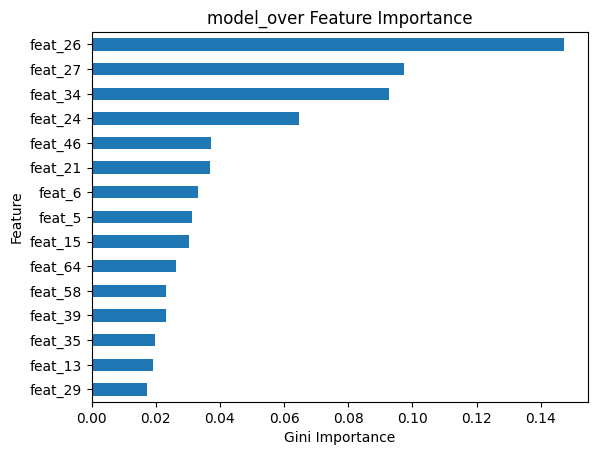

In [30]:
# Get importances

importances = model_over.named_steps["decisiontreeclassifier"].feature_importances_

# Put importances into a Series
feat_imp = pd.Series(importances, index=X_train_over.columns)
# Plot series

feat_imp.sort_values(ascending=True).tail(15).plot(kind="barh")

plt.xlabel("Gini Importance")
plt.ylabel("Feature")
plt.title("model_over Feature Importance");

We enhance this with a random forest and cross validation. We communicate the actual features at the end.

In [28]:
from sklearn.ensemble import RandomForestClassifier

clf = make_pipeline(
    SimpleImputer(),
    RandomForestClassifier(random_state=42)
)
print(clf)

Pipeline(steps=[('simpleimputer', SimpleImputer()),
                ('randomforestclassifier',
                 RandomForestClassifier(random_state=42))])


In [38]:
params = {
    "simpleimputer__strategy": ["mean","median"],
    "randomforestclassifier__max_depth": range(10,50,10),
    "randomforestclassifier__n_estimators":range(25,100,25)
}
params

{'simpleimputer__strategy': ['mean', 'median'],
 'randomforestclassifier__max_depth': range(10, 50, 10),
 'randomforestclassifier__n_estimators': range(25, 100, 25)}

In [39]:
model = GridSearchCV(clf, param_grid=params, cv=5, n_jobs=-1, verbose=1)
model

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'randomforestclassifier__max_depth': range(10, 50, 10), 'randomforestclassifier__n_estimators': range(25, 100, 25), 'simpleimputer__strategy': ['mean', 'median']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the comp

In [40]:
# Train model
model.fit(X_train_over, y_train_over)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'randomforestclassifier__max_depth': range(10, 50, 10), 'randomforestclassifier__n_estimators': range(25, 100, 25), 'simpleimputer__strategy': ['mean', 'median']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the comp

In [41]:
cv_results = pd.DataFrame(model.cv_results_)
cv_results.head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_randomforestclassifier__max_depth,param_randomforestclassifier__n_estimators,param_simpleimputer__strategy,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,1.046551,0.047666,0.010729,0.003982,10,25,mean,"{'randomforestclassifier__max_depth': 10, 'ran...",0.970294,0.966614,0.972397,0.972660,0.972923,0.970978,0.002372,21
1,1.197181,0.010752,0.014633,0.004166,10,25,median,"{'randomforestclassifier__max_depth': 10, 'ran...",0.972660,0.967140,0.962145,0.960831,0.969506,0.966456,0.004438,24
2,2.026940,0.037073,0.014946,0.003126,10,50,mean,"{'randomforestclassifier__max_depth': 10, 'ran...",0.974501,0.969769,0.972923,0.970557,0.973712,0.972292,0.001826,19
3,1.960411,0.063354,0.014095,0.002750,10,50,median,"{'randomforestclassifier__max_depth': 10, 'ran...",0.973186,0.973712,0.964774,0.963985,0.966351,0.968402,0.004194,23
4,2.932832,0.075694,0.021445,0.003577,10,75,mean,"{'randomforestclassifier__max_depth': 10, 'ran...",0.972923,0.972135,0.970557,0.971609,0.973186,0.972082,0.000946,20
5,3.036134,0.024892,0.022032,0.003591,10,75,median,"{'randomforestclassifier__max_depth': 10, 'ran...",0.975289,0.971872,0.962671,0.964511,0.968980,0.968665,0.004636,22
6,1.180740,0.027688,0.010488,0.001404,20,25,mean,"{'randomforestclassifier__max_depth': 20, 'ran...",0.995005,0.994742,0.992376,0.995794,0.995531,0.994690,0.001215,18
7,1.223758,0.023677,0.009495,0.001374,20,25,median,"{'randomforestclassifier__max_depth': 20, 'ran...",0.995794,0.994217,0.993691,0.995531,0.995005,0.994848,0.000790,17
8,2.215491,0.033570,0.021437,0.002151,20,50,mean,"{'randomforestclassifier__max_depth': 20, 'ran...",0.995794,0.995005,0.993954,0.996845,0.996320,0.995584,0.001017,16
9,2.302805,0.084899,0.020143,0.002146,20,50,median,"{'randomforestclassifier__max_depth': 20, 'ran...",0.996583,0.996583,0.994217,0.997108,0.995531,0.996004,0.001030,13


In [42]:
# Extract best hyperparameters
model.best_params_

{'randomforestclassifier__max_depth': 40,
 'randomforestclassifier__n_estimators': 50,
 'simpleimputer__strategy': 'median'}

We now have the best hyperparameters for our final model.

In [43]:
from sklearn.metrics import accuracy_score

acc_train = accuracy_score(model.predict(X_train), y_train)
acc_test = accuracy_score(model.predict(X_test), y_test)

print("Training Accuracy:", round(acc_train, 4))
print("Test Accuracy:", round(acc_test, 4))

Training Accuracy: 1.0
Test Accuracy: 1.0


In [44]:
y_test.value_counts()

bankrupt
False    1913
True       83
Name: count, dtype: int64

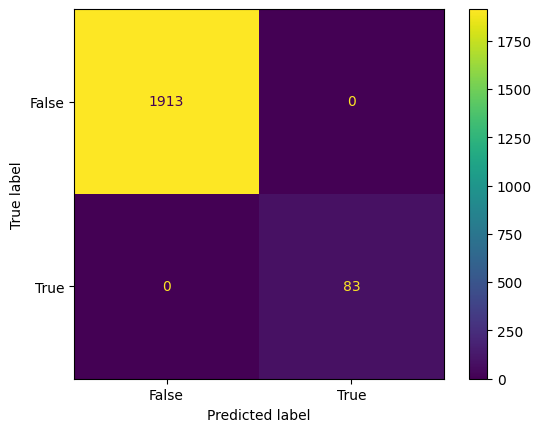

In [45]:
# Plot confusion matrix
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)

In [88]:
def make_predictions(data_filepath, model_filepath):
    # Wrangle JSON file
    X_test = wrangle(data_filepath)
    # Load model
    with open(model_filepath, "rb") as f:
        model=pickle.load(f)
    # Generate predictions
    y_test_pred = model.predict(X_test)
    # Put predictions into Series with name "bankrupt", and same index as X_test
    y_test_pred = pd.Series(y_test_pred, index=X_test.index, name="bankrupt")
    return y_test_pred

In [90]:
y_test_pred = make_predictions(
    data_filepath="/Users/hirecheariles/Documents/Cours/Master Finance/ML/poland-bankruptcy-data-2009-mvp-features.json.gz",
    model_filepath="/Users/hirecheariles/Documents/Cours/Master Finance/ML/best_model.pkl",
)

print("predictions shape:", y_test_pred.shape)
y_test_pred.head()

predictions shape: (526,)


company_id
4     False
32    False
34    False
36    False
40    False
Name: bankrupt, dtype: bool

### Now feature analysis

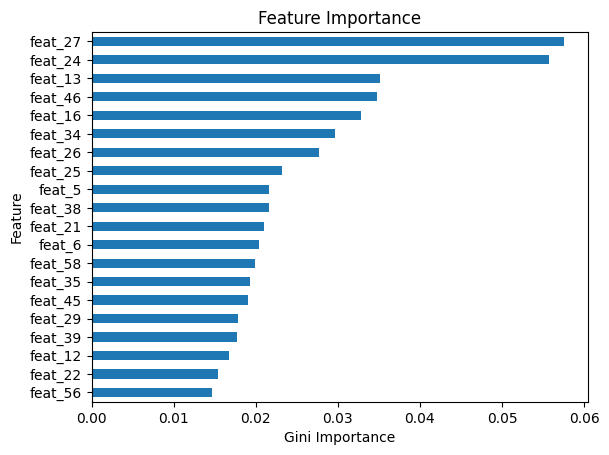

In [54]:
# Get feature names from training data
features = X_train.columns
# Extract importances from model
importances = model.best_estimator_.named_steps["randomforestclassifier"].feature_importances_
# Create a series with feature names and importances
feat_imp = pd.Series(importances, index=features).sort_values()
# Plot 10 most important features
feat_imp.tail(20).plot(kind="barh")

plt.xlabel("Gini Importance")
plt.ylabel("Feature")
plt.title("Feature Importance");

| feature    | description                                                                                                         |  
| :--------- | :------------------------------------------------------------------------------------------------------------------ |   
| **feat_5**  | [(cash + short-term securities + receivables - short-term liabilities) / (operating expenses - depreciation)] * 365 |  
| **feat_6**  | retained earnings / total assets                                                                                    |  
| **feat_12** | gross profit / short-term liabilities                                                                               |  
| **feat_13** | (gross profit + depreciation) / sales                                                                               |  
| **feat_16** | (gross profit + depreciation) / total liabilities                                                                   |  
| **feat_21** | sales (n) / sales (n-1)                                                                                             |  
| **feat_22** | profit on operating activities / total assets                                                                       |  
| **feat_25** | (equity - share capital) / total assets                                                                             |  
| **feat_26** | (net profit + depreciation) / total liabilities                                                                     |  
| **feat_27** | profit on operating activities / financial expenses                                                                 |  
| **feat_34** | operating expenses / total liabilities                                                                              |  
| **feat_35** | profit on sales / total assets                                                                                      |  
| **feat_38** | constant capital / total assets                                                                                     |  
| **feat_39** | profit on sales / sales                                                                                             |   
| **feat_46** | (current assets - inventory) / short-term liabilities                                                               |    
| **feat_58** | total costs /total sales                                                                                            |  

Here are the 20 features with the highest Gini importance. Regarding the data that is provided by SMB, some of them migh be less convenient to otbrain. For example

**feat_24** | gross profit (in 3 years) / total assets  

requires __gross profit in 3 years__ ; not all SMB can provide this information.

 feat_45 (net profit / inventory) — service companies often have near-zero inventory, causing division-by-zero or extreme outliers that destabilize the model.

feat_56 ((sales - cost of products sold) / sales) — "cost of products sold" is not an explicit line item in French (or most European) accounting standards. It requires approximation, introducing inconsistency across firms.

### We shorten the scope to the most convenient ones in terms of explainability.

In [75]:
ACCOUNTING_FEATURES = [
    "feat_5",   # cash flow adequacy (days)
    "feat_6",   # retained earnings / total assets
    "feat_12",  # gross profit / short-term liabilities
    "feat_13",  # (gross profit + depreciation) / sales
    "feat_16",  # (gross profit + depreciation) / total liabilities
    "feat_21",  # sales growth (N / N-1)  ← requires prior year, shown in liasse
    "feat_22",  # operating profit / total assets
    "feat_25",  # (equity - share capital) / total assets
    "feat_26",  # (net profit + depreciation) / total liabilities
    "feat_27",  # operating profit / financial expenses
    "feat_34",  # operating expenses / total liabilities
    "feat_35",  # profit on sales / total assets
    "feat_38",  # constant capital / total assets
    "feat_39",  # profit on sales / sales
    "feat_46",  # (current assets - inventory) / short-term liabilities
    "feat_58",  # total costs / total revenues
]

X_sel = df[ACCOUNTING_FEATURES]
y     = df["bankrupt"]

X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(
    X_sel, y, test_size=0.2, random_state=42
)

print(f"Training on {len(ACCOUNTING_FEATURES)} features")
print(f"Train: {X_train_sel.shape} | Test: {X_test_sel.shape}")

Training on 16 features
Train: (7981, 16) | Test: (1996, 16)


In [76]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Oversample on selected features only
over_sampler = RandomOverSampler(random_state=42)
X_train_over_sel, y_train_over_sel = over_sampler.fit_resample(X_train_sel, y_train_sel)

# Pipeline: impute → random forest
clf_sel = make_pipeline(
    SimpleImputer(strategy="median"),
    RandomForestClassifier(random_state=42, class_weight="balanced")
)

params = {
    "simpleimputer__strategy":             ["mean", "median"],
    "randomforestclassifier__max_depth":   range(10, 50, 10),
    "randomforestclassifier__n_estimators": range(25, 100, 25),
}

model_sel = GridSearchCV(clf_sel, param_grid=params, cv=5, n_jobs=-1,
                         scoring="roc_auc", verbose=1)
model_sel.fit(X_train_over_sel, y_train_over_sel)

print("Best params:", model_sel.best_params_)
print("Best CV AUC:", round(model_sel.best_score_, 4))

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best params: {'randomforestclassifier__max_depth': 20, 'randomforestclassifier__n_estimators': 75, 'simpleimputer__strategy': 'median'}
Best CV AUC: 1.0


Test AUC  : 0.9114
Gini      : 0.8228

              precision    recall  f1-score   support

       False       0.97      0.99      0.98      1913
        True       0.68      0.25      0.37        83

    accuracy                           0.96      1996
   macro avg       0.82      0.62      0.67      1996
weighted avg       0.96      0.96      0.96      1996



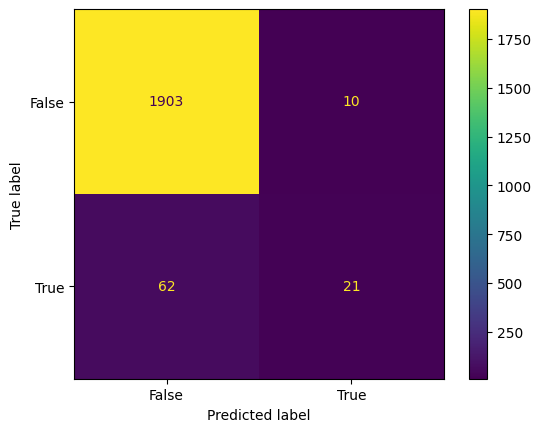

In [80]:
from sklearn.metrics import roc_auc_score, classification_report, ConfusionMatrixDisplay

y_pred_sel  = model_sel.predict(X_test_sel)
y_proba_sel = model_sel.predict_proba(X_test_sel)[:, 1]

print(f"Test AUC  : {roc_auc_score(y_test_sel, y_proba_sel):.4f}")
print(f"Gini      : {2 * roc_auc_score(y_test_sel, y_proba_sel) - 1:.4f}")
print()
print(classification_report(y_test_sel, y_pred_sel))

ConfusionMatrixDisplay.from_estimator(model_sel, X_test_sel, y_test_sel)

In [85]:
with open("best_model_accounting.pkl", "wb") as f:
    pickle.dump(model_sel, f)

print("Model saved → best_model_accounting.pkl")


def prob_to_score(prob):
    prob = np.clip(prob, 1e-6, 1 - 1e-6)
    log_odds = np.log((1 - prob) / prob)
    return np.clip((log_odds + 6) / 12 * 100, 0, 100).astype(int)


def make_scores(data_filepath, model_filepath, features=ACCOUNTING_FEATURES):
    X_test = wrangle(data_filepath)[features]
    with open(model_filepath, "rb") as f:
        model = pickle.load(f)
    proba  = model.predict_proba(X_test)[:, 1]
    scores = prob_to_score(proba)
    return pd.Series(scores, index=X_test.index, name="credit_score")

Model saved → best_model_accounting.pkl


### Now we finally want to convert the actual probability that is computed by the alogrithm into a score such that we get something on a continuous scale.

In [91]:
import numpy as np

def prob_to_score(prob):
    """
    P(bankrupt) → score 0–100.
    100 = perfectly healthy, 0 = certain bankruptcy.
    Uses log-odds so the scale is linear in risk perception,
    not just a flipped probability.
    """
    # Clip to avoid log(0)
    prob = np.clip(prob, 1e-6, 1 - 1e-6)
    
    # Log-odds of being HEALTHY (higher = safer)
    log_odds = np.log((1 - prob) / prob)
    
    # Typical range of log-odds is roughly -6 to +6 → rescale to 0–100
    score = (log_odds + 6) / 12 * 100
    
    return np.clip(score, 0, 100).astype(int)


def make_scores(data_filepath, model_filepath):
    # Wrangle JSON file — same as make_predictions
    X_test = wrangle(data_filepath)
    
    # Load your saved Random Forest model
    with open(model_filepath, "rb") as f:
        model = pickle.load(f)
    
    # Get P(bankrupt) — second column of predict_proba output
    proba = model.predict_proba(X_test)[:, 1]
    
    # Convert to credit scores
    scores = prob_to_score(proba)
    
    return pd.Series(scores, index=X_test.index, name="credit_score")

Score distribution:
count    526.000000
mean      81.015209
std       14.971966
min        0.000000
25%       70.000000
50%       82.000000
75%      100.000000
max      100.000000
Name: credit_score, dtype: float64


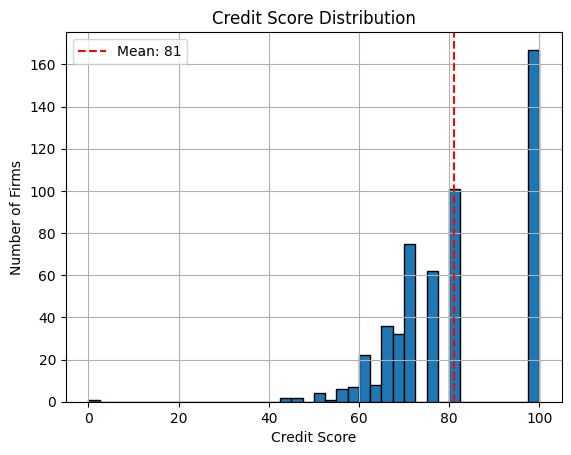

company_id
4       82
32      82
34      66
36      82
40      70
81      66
97     100
108     72
120    100
132     72
Name: credit_score, dtype: int64

In [93]:
scores = make_scores(
    data_filepath="poland-bankruptcy-data-2009-mvp-features.json.gz",
    model_filepath="best_model.pkl",
)

print("Score distribution:")
print(scores.describe())

# Visual check
scores.hist(bins=40, edgecolor="black")
plt.xlabel("Credit Score")
plt.ylabel("Number of Firms")
plt.title("Credit Score Distribution")
plt.axvline(scores.mean(), color="red", linestyle="--", label=f"Mean: {scores.mean():.0f}")
plt.legend()
plt.show()

scores.head(10)